In [1]:
import kagglehub
path = kagglehub.dataset_download("salader/dogsvscats")

100%|██████████| 1.06G/1.06G [00:26<00:00, 42.5MB/s]

Extracting files...


In [2]:
import os

# The dataset has been downloaded to the 'path' variable.
# Let's inspect the contents of this directory to understand its structure.
print(f"Contents of the downloaded dataset directory ({path}):")
for item in os.listdir(path):
    print(f"- {item}")

# At this point, 'data' is not yet loaded as a single object.
# You will typically use libraries like pandas, PIL, or TensorFlow/PyTorch
# to load specific files from within this 'path' directory, depending on their type.

Contents of the downloaded dataset directory (/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1):
- train
- catsvsdogs
- test


In [3]:
import os

# The dataset has been downloaded to the 'path' variable.
# Let's inspect the contents of this directory to understand its structure.
# print(f"Contents of the downloaded dataset directory ({path}):")
# for item in os.listdir(path):
#     print(f"- {item}")

# At this point, 'data' is not yet loaded as a single object.
# You will typically use libraries like pandas, PIL, or TensorFlow/PyTorch
# to load specific files from within this 'path' directory, depending on their type.

data_path = path

train_path = os.path.join(data_path, "train")
test_path = os.path.join(data_path, "test")

print(f"Corrected data_path: {data_path}")
print(f"Corrected train_path: {train_path}")
print(f"Corrected test_path: {test_path}")

Corrected data_path: /root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1
Corrected train_path: /root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/train
Corrected test_path: /root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/test


In [4]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [5]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [7]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [8]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
       rescale=1.0/255,
       validation_split=0.2)

IMG_SIZE = 150
train_gen = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [11]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

In [12]:
history = model.fit(train_gen,epochs=10,validation_data=val_gen)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8551 - loss: 0.3280

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 136ms/step - accuracy: 0.8552 - loss: 0.3278 - val_accuracy: 0.9273 - val_loss: 0.1781
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 137ms/step - accuracy: 0.9454 - loss: 0.1429 - val_accuracy: 0.9330 - val_loss: 0.1609
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 139ms/step - accuracy: 0.9643 - loss: 0.1002 - val_accuracy: 0.9202 - val_loss: 0.2078
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - accuracy: 0.9746 - loss: 0.0725 - val_accuracy: 0.9370 - val_loss: 0.1673
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.9844 - loss: 0.0495 - val_accuracy: 0.9425 - val_loss: 0.1469
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.9893 - loss: 0.0333 - val_accuracy: 0.9352 - val_loss: 0.1864
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.9945 - loss: 0.0228 - val_accuracy: 0.9430 - val_loss: 0.1695
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 143ms/step - accuracy: 0.9978 - loss: 0.0147 - val

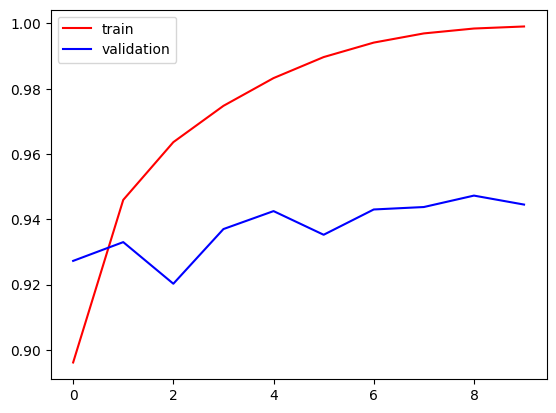

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

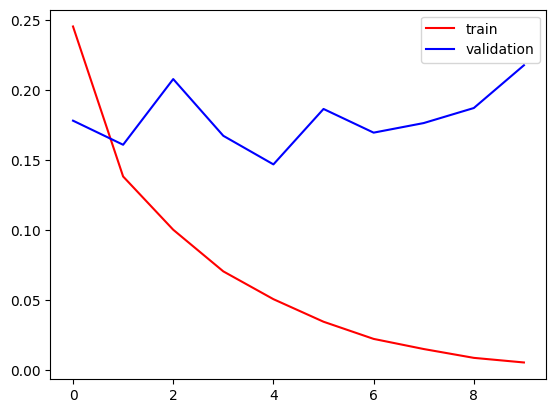

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()